# BÀI TẬP: MEDICAL INSURANCE COST
**Nguồn:** kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset



## Setup

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')


csv_path = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [3]:
# TODO
import pandas as pd
print('So hang',df.shape[0],'So cot', df.shape[1])
print()
df.info

So hang 1338 So cot 7



<bound method DataFrame.info of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>

## A.2. Missing values & Duplicate data

In [4]:
# TODO
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'Khong cot nao thieu du lieu')
print()
print('So cot duplicate: ', df.duplicated().sum())


Khong cot nao thieu du lieu

So cot duplicate:  1


## A.3. Invalid values

In [7]:
# TODO
print('age <= 0:', (df['age'] <= 0).sum())
print('bmi <= 0:', (df['bmi'] <= 0).sum())
print('children < 0:', (df['children'] <  0).sum())
print('sex khong hop le:', (~df['sex'].isin(['male', 'female'])).sum())
print('smoker khong hop le:', (~df['smoker'].isin(['yes', 'no'])).sum())
print("region không hợp lệ:",
      (~df["region"].isin(["southwest", "southeast", "northwest", "northeast"])).sum())
print('=> Du lieu kha sach: Khong missing, khong duplicate, khong gia tri khong hop le.')


age <= 0: 0
bmi <= 0: 0
children < 0: 0
sex khong hop le: 0
smoker khong hop le: 0
region không hợp lệ: 0
=> Du lieu kha sach: Khong missing, khong duplicate, khong gia tri khong hop le.


## A.4. Create a new column
Tạo cột `bmi_group`: Normal (<25), Overweight (25-30), Obese (>=30).

In [8]:
# TODO
df['bmi_group'] = 'Obese'
df.loc[df['bmi'] < 30, 'bmi_group'] = 'Overweight'
df.loc[df['bmi'] < 25, 'bmi_group'] = 'Normal'
df[['bmi', 'bmi_group']].head()

,bmi,bmi_group
0,27.900,Overweight
1,33.770,Obese
2,33.000,Obese
3,22.705,Normal
4,28.880,Overweight


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [11]:
# TODO
columns = ['age', 'bmi', 'children', 'charges']
for col in columns:
    print(col)
    mean_, median_, mode_ = df[col].mean(), df[col].median(), df[col].mode()[0]
    print(f'{col}: Mean = {mean_:.2f}, Median = {median_:.2f}, Mode = {mode_:.2f}')


age
age: Mean = 39.21, Median = 39.00, Mode = 18.00
bmi
bmi: Mean = 30.66, Median = 30.40, Mode = 32.30
children
children: Mean = 1.09, Median = 1.00, Mode = 0.00
charges
charges: Mean = 13270.42, Median = 9382.03, Mode = 1639.56


## Group 2 — Dispersion

In [12]:
# TODO
columns = ['age', 'bmi', 'children', 'charges']
for col in columns:
    s = df[col]
    range_ = s.max() - s.min()
    std_ = s.std()
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    cv = std_ / s.mean()
    print(f'{col}')
    print(f'Range = {range_:.2f}, Std = {std_:.2f}, IQR = {iqr:.2f}, CV = {cv:.2f}')

age
Range = 46.00, Std = 14.05, IQR = 24.00, CV = 0.36
bmi
Range = 37.17, Std = 6.10, IQR = 8.40, CV = 0.20
children
Range = 5.00, Std = 1.21, IQR = 2.00, CV = 1.10
charges
Range = 62648.55, Std = 12110.01, IQR = 11899.63, CV = 0.91


## Group 3 — Location and Shape

--- age ---
P25=27.00, P50=39.00, P75=51.00
Skewness=0.06, Kurtosis=-1.24
--- bmi ---
P25=26.30, P50=30.40, P75=34.69
Skewness=0.28, Kurtosis=-0.06
--- children ---
P25=0.00, P50=1.00, P75=2.00
Skewness=0.94, Kurtosis=0.20
--- charges ---
P25=4740.29, P50=9382.03, P75=16639.91
Skewness=1.51, Kurtosis=1.60


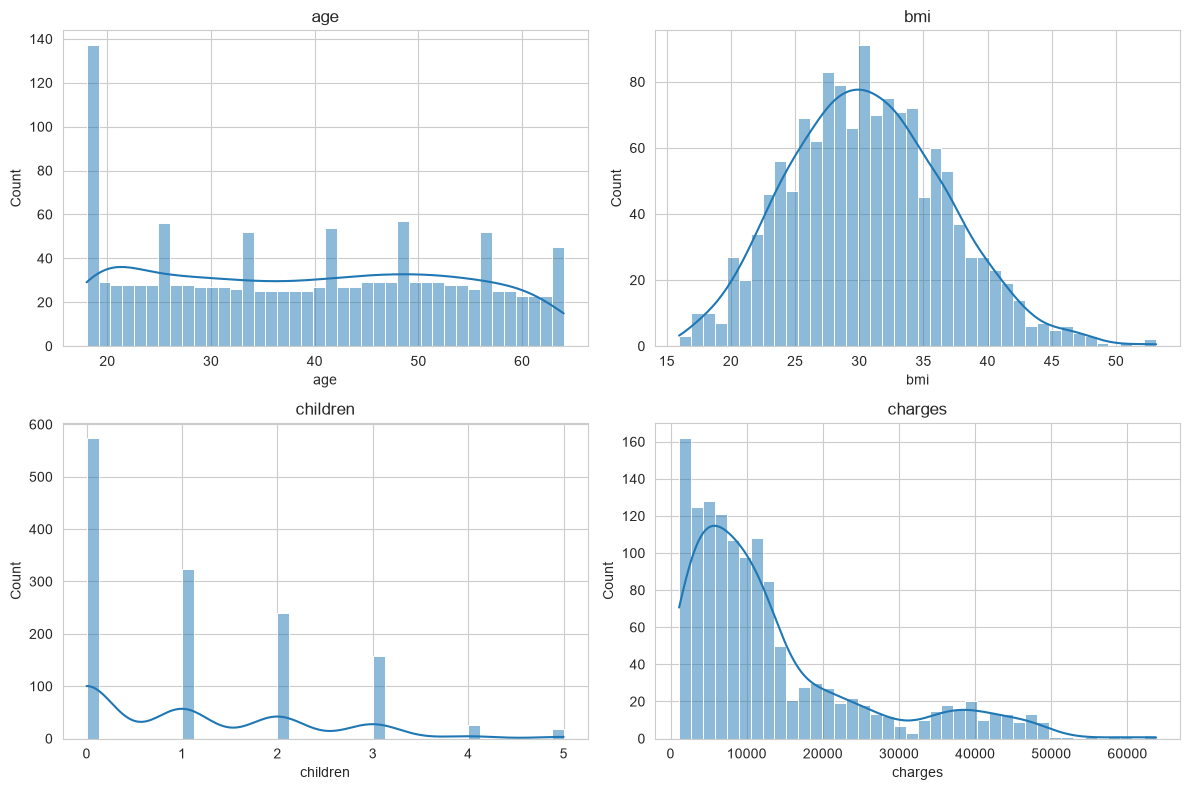

In [16]:
# TODO
columns = ["age", "bmi", "children", "charges"]
for col in columns:
    s = df[col]
    skew_, kurt_ = stats.skew(s), stats.kurtosis(s)
    print(f"--- {col} ---")
    print(f"P25={s.quantile(0.25):.2f}, P50={s.quantile(0.5):.2f}, P75={s.quantile(0.75):.2f}")
    print(f"Skewness={skew_:.2f}, Kurtosis={kurt_:.2f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df['age'], bins=40, kde=True, ax=axes[0, 0]); axes[0, 0].set_title('age')
sns.histplot(df['bmi'], bins=40, kde=True, ax=axes[0, 1]); axes[0, 1].set_title('bmi')
sns.histplot(df['children'], bins=40, kde=True, ax=axes[1, 0]); axes[1, 0].set_title('children')
sns.histplot(df['charges'], bins=40, kde=True, ax=axes[1, 1]); axes[1, 1].set_title('charges')
plt.tight_layout()
plt.show()

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Người hút thuốc trả chi phí cao hơn bao nhiêu lần so với người không hút, và có đồng đều giữa các vùng không?

In [ ]:
# TODO


## Câu hỏi 2: BMI có tương quan với chi phí mạnh hơn ở nhóm hút thuốc hay không hút thuốc?

In [ ]:
# TODO


## Câu hỏi 3: Vùng nào có chi phí bảo hiểm trung bình cao nhất?

In [ ]:
# TODO


## Câu hỏi 4: Số lượng con cái có làm tăng chi phí bảo hiểm không?

In [ ]:
# TODO


## Câu hỏi 5: Tuổi có tương quan với chi phí bảo hiểm không?

In [ ]:
# TODO


## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

*(Viết insight của bạn vào đây...)*